# Setup

## Packages

In [2]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point
from lenstronomy.Plots.lens_plot import lens_model_plot
from lenstronomy.Util import util

xgfs_normal6 = 255**-1 * np.asarray([(64, 83, 211), (221, 179, 16), (181, 29, 20), (0, 190, 255), (251, 73, 176), (0, 178, 93), (202, 202, 202)])
xgfs_normal12 = 255**-1 * np.asarray([(235, 172, 35), (184, 0, 88), (0, 140, 249), (0, 110, 0), (0, 187, 173), (209, 99, 230), (178, 69, 2), (255, 146, 135), (89, 84, 214), (0, 198, 248), (135, 133, 0), (0, 167, 108), (189, 189, 189)])
xgfs_bright6 = 255**-1 * np.asarray([(239, 230, 69), (233, 53, 161), (0, 227, 255), (225, 86, 44), (83, 126, 255), (0, 203, 133), (238, 238, 238)])
xgfs_dark6 = 255**-1 * np.asarray([(0, 89, 0), (0, 0, 120), (73, 13, 0), (138, 3, 79), (0, 90, 138), (68, 53, 0), (88, 88, 88)])
xgfs_fancy6 = 255**-1 * np.asarray([(86, 100, 26), (192, 175, 251), (230, 161, 118), (0, 103, 138), (152, 68, 100), (94, 204, 171), (205, 205, 205)])
xgfs_tarnish6 = 255**-1 * np.asarray([(39, 77, 82), (199, 162, 166), (129, 139, 112), (96, 78, 60), (140, 159, 183), (121, 104, 128), (192, 192, 192)])

## Parameters

In [3]:
from params_B1422_231 import *

v_obs = np.asarray([0,0]) * km / second
v_lens = np.asarray([500,500]) * km / second
v_source = np.asarray([0,0]) * km / second

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)

# observational errors
t_int = 10 * year
sigma_delta_theta = 0.1 * muas
N_obs = 300

sigma_mu_fit = 2*np.sqrt(3) * sigma_delta_theta / np.sqrt(N_obs * t_int**2) # proper motion fit uncertainty
sigma_acc_fit = 12*np.sqrt(5) * sigma_delta_theta / np.sqrt(N_obs * t_int**4) # acceleration fit uncertainty

print('sigma_mu_fit = %.2g muas/yr' % (sigma_mu_fit/muasy))
print('sigma_acc_fit = %.2g muas/yr^2' % (sigma_acc_fit/muasyy))

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.037 muas = 0.183e-12 rad
theta_E_star =  1.400 muas
sigma_mu_fit = 0.002 muas/yr
sigma_acc_fit = 0.0015 muas/yr^2


## Inputs from macro-lens model

In [4]:
filename = 'macro_lens_results.npz'
results = np.load(filename)

kappa_fit = results['kappa_fit']
gamma1_fit = results['gamma1_fit']
gamma2_fit = results['gamma2_fit']
mag_fit = results['mag_fit']
hessian_fit = results['hessian_fit']
jacobian_fit = results['jacobian_fit']
inv_jacobian_fit = results['inv_jacobian_fit']
eigvals_fit = results['eigvals_fit']
eigvecs_fit = results['eigvecs_fit']

In [9]:
fraction_sub = 0.5
kappa_star = 0.05

In [10]:
kappa_l = kappa_fit * fraction_sub # DM microlens convergence at image locations

vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1) # lensed image proper motion vectors
mu_tilde = np.linalg.norm(vec_mu_tilde, axis=1) # lensed image proper motion magnitudes

# angle of vec_mu_tilde with respect to RA direction
zeta = np.arctan2(vec_mu_tilde[:,1], vec_mu_tilde[:,0])

print('kappa_l =', kappa_l)
print('mu_tilde =', mu_tilde / muasy, 'muas/yr')
print('zeta =', zeta / degree, 'degree')

kappa_l = [0.1923961  0.23139261 0.1834638  0.85749579]
mu_tilde = [0.8066115  1.13117001 0.41101901 0.04532126] muas/yr
zeta = [-148.93020601   49.75872011 -106.01920173   76.88233461] degree


# Analytic Power Spectrum

## Power in individual images

### Calculation

In [11]:
vec_omega = year**-1 * np.logspace(-3,3,int(1e3))
vec_M_l = np.asarray([1e-3,1e-4,1e-5,1e-6]) * M_Solar
arr_C_ij_l = np.zeros((len(kappa_l),len(vec_M_l),2,2,len(vec_omega)))

vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)],[np.zeros_like(vec_C_star),vec_C_star]])
arr_C_pq_star = np.einsum('aqj,apjm->apqm', inv_jacobian_fit,np.einsum('api,ijm->apjm',inv_jacobian_fit, arr_C_ij_star))

vec_C_EPIC = C_EPIC(vec_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

for j, M_l in enumerate(vec_M_l):
    rho_s = 1e1 * M_Solar * pc**-3; 
    r_s = (M_l/(rho_s *(4*np.pi*np.exp(1/2))))**(1/3) 
    gamma_l = r_s/d_lens;
    theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
    print("theta_E_l = %.3g muas" % (theta_E_l / muas))
    print("r_s = %.2g pc" % (r_s/pc))
    for i in range(len(kappa_l)):
        arr_C_ij_l[i,j] = kappa_l[i] * theta_E_l**2 / vec_omega * C_ij_integral(gamma_l/mu_tilde[i] * vec_omega, zeta[i])
arr_C_pq_l = np.einsum('aqj,abpjm->abpqm',inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

theta_E_l = 0.0809 muas
r_s = 0.017 pc
theta_E_l = 0.0256 muas
r_s = 0.0078 pc
theta_E_l = 0.00809 muas
r_s = 0.0036 pc
theta_E_l = 0.00256 muas
r_s = 0.0017 pc


### Plots

In [12]:
sns.color_palette(xgfs_fancy6)

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

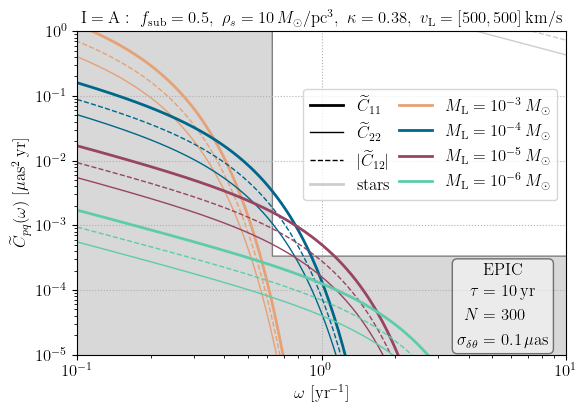

In [13]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_l = 0
for i in [idx_l]:
        
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=2,
                label='stars')
                #label=r'$\kappa_* = %.2g\\ M_* = %.1g \, M_\odot$' % (kappa_star,(M_star/M_Solar)))
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=1)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=1,ls='dashed')
        
        for j, M_l in enumerate(vec_M_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,1e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(0.85e1,5.6e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

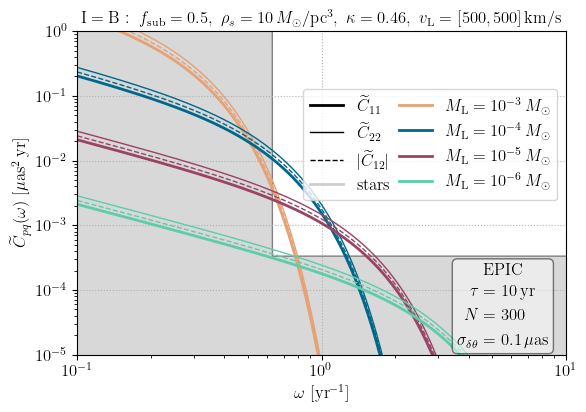

In [14]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_l = 1
for i in [idx_l]:
        
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=2,
                label='stars')
                #label=r'$\kappa_* = %.2g\\ M_* = %.1g \, M_\odot$' % (kappa_star,(M_star/M_Solar)))
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=1)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=1,ls='dashed')
        
        for j, M_l in enumerate(vec_M_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,1e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(0.85e1,5.6e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
#fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

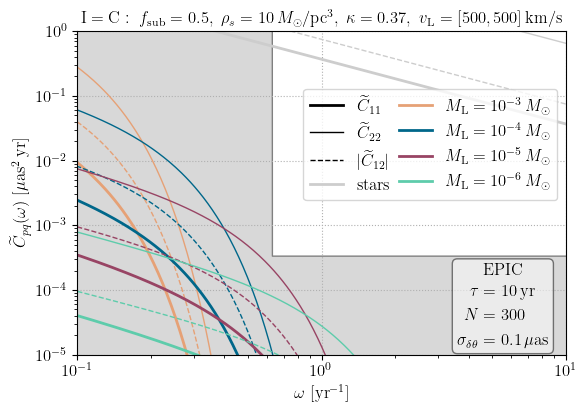

In [15]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_l = 2
for i in [idx_l]:
        
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=2,
                label='stars')
                #label=r'$\kappa_* = %.2g\\ M_* = %.1g \, M_\odot$' % (kappa_star,(M_star/M_Solar)))
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=1)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=1,ls='dashed')
        
        for j, M_l in enumerate(vec_M_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,1e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(0.85e1,5.6e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
#fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

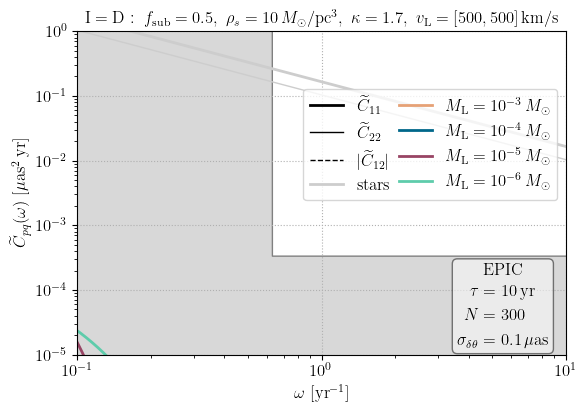

In [16]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_l[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_l[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_l = 3
for i in [idx_l]:
        
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=2,
                label='stars')
                #label=r'$\kappa_* = %.2g\\ M_* = %.1g \, M_\odot$' % (kappa_star,(M_star/M_Solar)))
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=1)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=1,ls='dashed')
        
        for j, M_l in enumerate(vec_M_l):
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_l[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_l[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_l/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_EPIC/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,1e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(0.85e1,5.6e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='right',va='center',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_l], fraction_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_l], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
#fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

# Sensitivity

## Stellar background

In [17]:
theta_fit = 10 * muas
N_fit = kappa_star * Sigma_crit(d_lens, d_source, d_lens_source) / M_star * np.pi * theta_fit**2 * d_lens**2
print('N_fit = %.2g' % N_fit)

Delta_theta = mu_tilde * t_int
print('Delta_theta = %.2g muas' % (Delta_theta[0]/muas)) #image A

print('theta_E_star = %.2g muas' % (theta_E_star/muas))

sigma_acc_star = np.sqrt(np.linalg.det(inv_jacobian_fit[0]) * 4 * theta_E_star**4 * mu_tilde[0]**4 / theta_fit**6)
sigma_acc_star_unlensed = np.sqrt(4 * theta_E_star**4 * mu_tilde[0]**4 / theta_fit**6)

print('sigma_acc_star^2 = %.3g muas^2/yr^4' % (sigma_acc_star**2 / muasyy**2))
print('sigma_acc_star = %.3g muas/yr^2' % (sigma_acc_star / muasyy))
print('sigma_acc_star_unlensed = %.3g muas/yr^2' % (sigma_acc_star_unlensed / muasyy))


N_fit = 2.5
Delta_theta = 8.1 muas
theta_E_star = 1.4 muas
sigma_acc_star^2 = 4.47e-05 muas^2/yr^4
sigma_acc_star = 0.00668 muas/yr^2
sigma_acc_star_unlensed = 0.00255 muas/yr^2


## Instrument-limited

In [186]:
sigma_acc_EPIC = np.sqrt(720 * sigma_delta_theta**2 / (t_int**4 * N_obs))

print(r'sigma_acc_EPIC^2 = %.2g muas^2/yr^4' % (sigma_acc_EPIC**2/muasyy**2))
print(r'sigma_acc_EPIC = %.2g muas/yr^2' % (sigma_acc_EPIC/muasyy))

sigma_acc_EPIC^2 = 2.4e-06 muas^2/yr^4
sigma_acc_EPIC = 0.0015 muas/yr^2


\begin{align}
C^\mathrm{AB}_{ij} = \langle (\theta^\mathrm{A}_i - \theta^\mathrm{B}_i) (\theta^\mathrm{A}_j - \theta^\mathrm{B}_j) \rangle = C^\mathrm{A}_{ij} + C^\mathrm{B}_{ij}
\end{align}

Compute eigenvalues of $C_{ij}^\mathrm{AB}$, compare largest to $C_{ii}^\mathrm{EPIC}$ (no sum) at the most favorable frequency. When SNR > 1, that parameter space point of $\kappa_l$, $M_l$, $r_s$ is detectable.

Fixed velocity for now, marginalize over velocity later. Also better to do weighted sum in SNR, though lowest signal frequency dominates.



### Setup

In [289]:
f_sub = 1
list_r_s = 10**np.arange(-4.5,1.5,0.04) * pc
list_rho_s = 10**np.arange(-2.,5.01,0.04) * M_Solar/pc**3
arr_r_s, arr_rho_s = np.meshgrid(list_r_s, list_rho_s)
arr_M_l = np.asarray([[4*np.pi*np.exp(1/2) * rho_s * r_s**3 for r_s in list_r_s] for rho_s in list_rho_s])
arr_gamma_l = arr_r_s / d_lens
arr_theta_E_l = theta_E(arr_M_l, d_lens, d_source, d_lens_source)
list_n = np.arange(1,N_obs)
list_omega = 2 * np.pi / t_int * list_n # list of angular frequencies sampled in DFT
list_omega_out = np.logspace(-6,2,int(5e2)) * 2 * np.pi / t_int # list of angular frequencies outside of DFT (for proper motion and acceleration integrals)

arr_crit = arr_rho_s * arr_r_s / Sigma_crit(d_lens, d_source, d_lens_source) # critical surface density (crude estimate)


# predictions
list_M_200 = 10**np.arange(-10.,8,0.1) * M_Solar
list_r_s_pred = r_s_Einasto_200(list_M_200)
list_rho_s_pred = 20*rho_s_Einasto_200(list_M_200)
list_M_s_pred = M_enc_Einasto(list_r_s_pred, list_rho_s_pred, list_r_s_pred)


In [290]:
len(list_rho_s),len(list_r_s), np.shape(arr_gamma_l), np.shape(arr_M_l), len(list_omega)

(176, 150, (176, 150), (176, 150), 299)

### Scan for temporal power spectrum

In [291]:
arr_C_ij_l = np.zeros((len(kappa_l),len(list_rho_s),len(list_r_s),2,2,len(list_omega)))
for i in range(len(kappa_l)):
    arr_C_ij_l[i] = f_sub * kappa_l[i] * arr_theta_E_l[:,:,None,None,None]**2 / list_omega * np.transpose(C_ij_integral(arr_gamma_l[:,:,None]/mu_tilde[i] * list_omega, zeta[i]),axes=(2,3,0,1,4))
arr_C_pq_l = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_l)) # implement macrolensing of power spectrum

# added power spectra for all image pairs
N_images = len(kappa_l)
N_pairs = N_images * (N_images - 1) // 2
arr_Delta_C_pq_l = np.zeros((N_pairs,len(list_rho_s),len(list_r_s),2,2,len(list_omega))) # shape = N_pairs, len(list_rho_s), len(list_r_s), 2, 2,  len(list_omega)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_Delta_C_pq_l[count] = arr_C_pq_l[i] + arr_C_pq_l[j]
        count+=1

arr_Delta_C_pq_l = np.transpose(arr_Delta_C_pq_l, axes=(1,2,0,5,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, len(list_omega), 2, 2
arr_Delta_C_mag_l = np.max(np.linalg.eigvals(arr_Delta_C_pq_l),axis=-1) # magnitude of largest eigenvalue

arr_C_EPIC = C_EPIC(list_omega, t_int=t_int, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta) #[None,None,None,:]

arr_SNR_EPIC = np.max(arr_Delta_C_mag_l / arr_C_EPIC, axis=(-2,-1))

### Subtraction

In [292]:
cos_fac = (12/N_obs**2) / (1 - np.cos(2 * np.pi * list_n / N_obs))
arr_Delta_C_mag_tilde = (1 - cos_fac) * arr_Delta_C_mag_l #+ (1/2) * cos_fac * np.sum(cos_fac * arr_Delta_C_mag_l, axis=-1)[:,:,:,None]
arr_SNR_EPIC_tilde = np.max(arr_Delta_C_mag_tilde / arr_C_EPIC, axis=(-2,-1))

### Scan for proper motion and acceleration

In [293]:
def smear_fac_mu(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 144 * (a * np.cos(a/2) - 2 * np.sin(a/2))**2 / a**6
def smear_fac_acc(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 14400 * (6 * a * np.cos(a/2) + (-12 + a**2) * np.sin(a/2))**2 / a**10

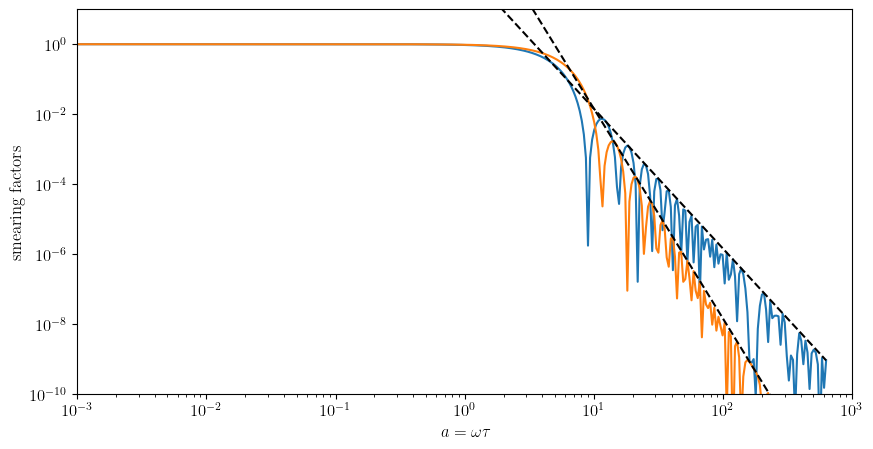

In [294]:
a = list_omega_out[1:] * t_int
list_smear_fac_mu = smear_fac_mu(a)
list_smear_fac_acc = smear_fac_acc(a)
fig,ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(a,list_smear_fac_mu)
ax.plot(a,list_smear_fac_acc)
ax.plot(a,144 * a**-4,'--k')
ax.plot(a,14400 * a**-6,'--k')
ax.set_xscale('log'); ax.set_yscale('log');
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-10,1e1);
ax.set_ylabel(r'smearing factors')
ax.set_xlabel(r'$a = \omega \tau$');

In [295]:
arr_C_ij_l_out = np.zeros((len(kappa_l),len(list_rho_s),len(list_r_s),2,2,len(list_omega_out)))
for i in range(len(kappa_l)):
    arr_C_ij_l_out[i] = f_sub * kappa_l[i] * arr_theta_E_l[:,:,None,None,None]**2 / list_omega_out * np.transpose(C_ij_integral(arr_gamma_l[:,:,None]/mu_tilde[i] * list_omega_out, zeta[i]),axes=(2,3,0,1,4))
arr_C_pq_l_out = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_l_out)) # implement macrolensing of power spectrum

# added power spectra for all image pairs
N_images = len(kappa_l)
N_pairs = N_images * (N_images - 1) // 2
arr_Delta_C_pq_l_out = np.zeros((N_pairs,len(list_rho_s),len(list_r_s),2,2,len(list_omega_out))) # shape = N_pairs, len(list_rho_s), len(list_r_s), 2, 2,  len(list_omega_out)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_Delta_C_pq_l_out[count] = arr_C_pq_l_out[i] + arr_C_pq_l_out[j]
        count+=1
        

# compute proper motion+acceleration covariance (factor of 2 in front is to count negative frequencies as well)
# arr_Delta_mu_pq_l_out = 2 * np.sum((list_omega_out[1:] - list_omega_out[:-1])/(2*np.pi) * list_omega_out[1:]**2 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
# arr_Delta_acc_pq_l_out = 2 * np.sum((list_omega_out[1:] - list_omega_out[:-1])/(2*np.pi) * list_omega_out[1:]**4 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
Delta_omega_out = list_omega_out[1:] - list_omega_out[:-1]
a = list_omega_out[1:] * t_int
list_smear_fac_mu = smear_fac_mu(a)
list_smear_fac_acc = smear_fac_acc(a)
arr_Delta_mu_pq_l_out = 2 * np.sum(list_smear_fac_mu * Delta_omega_out / (2*np.pi) * list_omega_out[1:]**2 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)
arr_Delta_acc_pq_l_out = 2 * np.sum(list_smear_fac_acc * Delta_omega_out / (2*np.pi) * list_omega_out[1:]**4 * arr_Delta_C_pq_l_out[:,:,:,:,:,1:],axis=-1)

arr_Delta_mu_pq_l_out = np.transpose(arr_Delta_mu_pq_l_out, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, 2, 2
arr_Delta_acc_pq_l_out = np.transpose(arr_Delta_acc_pq_l_out, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_s), N_pairs, 2, 2

arr_Delta_mu_mag_l_out = np.max(np.linalg.eigvals(arr_Delta_mu_pq_l_out),axis=-1) # magnitude of largest eigenvalue
arr_Delta_acc_mag_l_out = np.max(np.linalg.eigvals(arr_Delta_acc_pq_l_out),axis=-1) # magnitude of largest eigenvalue

arr_SNR_EPIC_mu = np.max(arr_Delta_mu_mag_l_out / sigma_mu_fit**2, axis=-1)
arr_SNR_EPIC_mu_tilde = np.max(arr_Delta_mu_mag_l_out / np.max(mu_tilde)**2, axis=-1)
arr_SNR_EPIC_acc = np.max(arr_Delta_acc_mag_l_out / sigma_acc_fit**2, axis=-1)

### Acceleration figure

In [296]:
list_rho_s.shape, list_r_s.shape, arr_Delta_acc_mag_l_out.shape, arr_M_l.shape

((176,), (150,), (176, 150, 6), (176, 150))

In [310]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

rho_s = 1 M_Solar / pc^3
rho_s = 10 M_Solar / pc^3


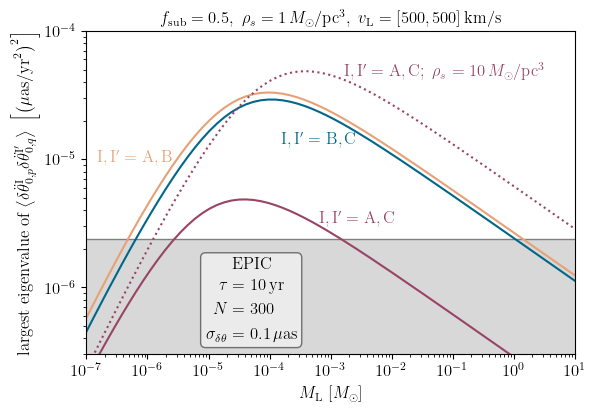

In [357]:
idx_rho_1 = 50; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_1]/(M_Solar / pc**3)))
idx_rho_2 = 75; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_2]/(M_Solar / pc**3)))


fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)

ax.fill_between(arr_M_l[idx_rho_1]/M_Solar,sigma_acc_EPIC**2 / muasyy**2,color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3))


ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,0] / muasyy**2, color=colors[2], label=r'$\mathrm{I,I^\prime = A,B}$') # AB
ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,3] / muasyy**2, color=colors[3], label=r'$\mathrm{I,I^\prime = B,C}$') # BC
ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,1] / muasyy**2, color=colors[4], label=r'$\mathrm{I,I^\prime = A,C}$') # AC
ax.plot(arr_M_l[idx_rho_2]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_2,:,1] / muasyy**2, ls='dotted', color=colors[4], label=r'$\mathrm{I,I^\prime = A,C}$\\$\rho_s = 10\,M_\odot / \mathrm{pc}^3$') # AC
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,2] / muasyy**2) # AD
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,4] / muasyy**2) # BD
#ax.plot(arr_M_l[idx_rho_1]/M_Solar, arr_Delta_acc_mag_l_out[idx_rho_1,:,5] / muasyy**2) # CD
#ax.legend(loc='upper right', bbox_to_anchor=(1, 1),ncol=2,labelspacing=0.5, columnspacing=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-7,1e1)
ax.set_ylim(3e-7,1e-4)
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'largest eigenvalue of $\big \langle \delta \ddot \theta^\mathrm{I}_{0,p} \delta \ddot \theta^\mathrm{I^\prime}_{0,q} \big \rangle~\left[\left(\mathrm{\mu as / yr}^2\right)^2\right]$')

idx_lab_0 = 55
ax.text(arr_M_l[idx_rho_1,idx_lab_0]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_0,0]/muasyy**2,r'$\mathrm{I,I^\prime = A,B}$',color=colors[2],ha='right',va='bottom')
idx_lab_1 = 80
ax.text(arr_M_l[idx_rho_1,idx_lab_1]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_1,3]/muasyy**2,r'$\mathrm{I,I^\prime = B,C}$',color=colors[3],ha='right',va='top')
idx_lab_2 = 75
ax.text(arr_M_l[idx_rho_1,idx_lab_2]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_1,idx_lab_2,1]/muasyy**2,r'$\mathrm{I,I^\prime = A,C}$',color=colors[4],ha='left',va='bottom')
idx_lab_3 = 70
ax.text(arr_M_l[idx_rho_2,idx_lab_3]/M_Solar,arr_Delta_acc_mag_l_out[idx_rho_2,idx_lab_3,1]/muasyy**2,r'$\mathrm{I,I^\prime = A,C};~\rho_s = 10\,M_\odot / \mathrm{pc}^3$',color=colors[4],ha='left',va='bottom')


ax.text(5e-5,1.7e-6,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((t_int/year),(N_obs),(sigma_delta_theta/muas)),
        ha='center',va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));

ax.set_title(r'$f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (fraction_sub, (list_rho_s[idx_rho_1]/(M_Solar/pc**3)), (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/acc.pdf', bbox_inches='tight')

### Reference

\begin{align}
\rho_s = \frac{M_\mathrm{L}}{4\pi \sqrt{e} r_s^3}
\end{align}

In [299]:
list_r_s_ref = np.logspace(-4,1,6) * pc
list_M_ref = np.logspace(-10,5,100) * M_Solar
arr_rho_s_ref = np.asarray([list_M_ref / (4*np.pi*np.exp(1/2)*r_s**3) for r_s in list_r_s_ref])
int_rho_s_ref_1 = interp1d(list_M_ref, arr_rho_s_ref[0], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_2 = interp1d(list_M_ref, arr_rho_s_ref[1], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_3 = interp1d(list_M_ref, arr_rho_s_ref[2], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_4 = interp1d(list_M_ref, arr_rho_s_ref[3], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_5 = interp1d(list_M_ref, arr_rho_s_ref[4], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_6 = interp1d(list_M_ref, arr_rho_s_ref[5], kind='linear', bounds_error=False, fill_value='extrapolate')

### Plot

In [300]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

/var/folders/sx/6kg505p567n15qgf8r0_mq8r0000gp/T/ipykernel_79296/1482459606.py:9: RuntimeWarning: divide by zero encountered in log10
  cs_SNR = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])


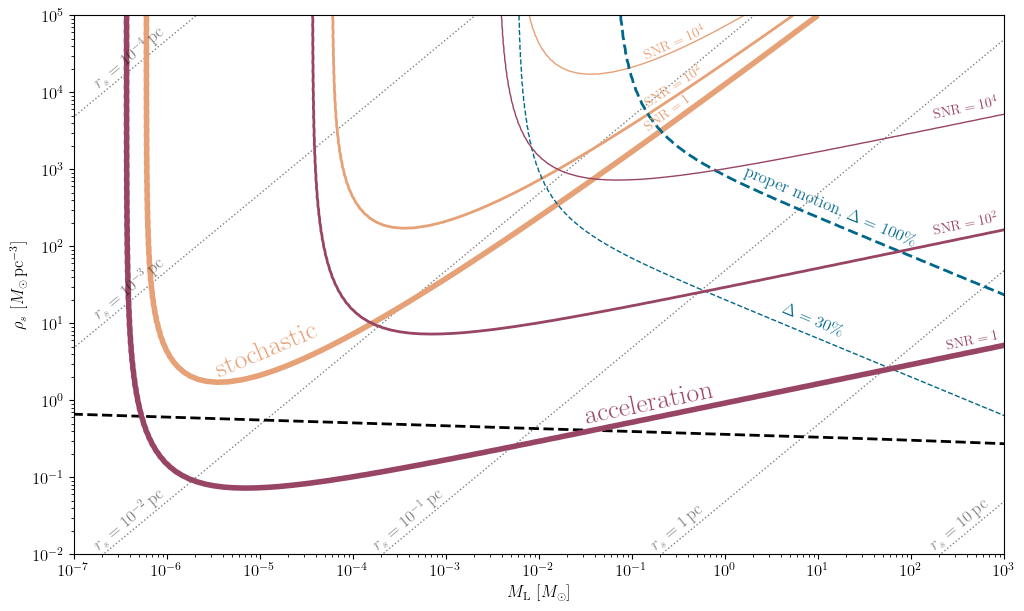

In [301]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
rotation = 40; 
rotation_2 = np.arctan(np.tan(rotation*degree) / 4) / degree
rotation_3 = np.arctan(np.tan(rotation*degree) / 2) / degree
#ax.scatter(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), c=np.log10(arr_r_s/pc), cmap='viridis', s=2);
ax.plot(list_M_s_pred/M_Solar, list_rho_s_pred/(M_Solar/pc**3), 'k--', lw=2)
for i in range(len(list_r_s_ref)):
    ax.plot(list_M_ref/M_Solar, arr_rho_s_ref[i]/(M_Solar/pc**3), color=(0,0,0,0.5), ls='dotted', lw=1)
cs_SNR = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])
cs_SNR_mu = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_mu_tilde), linestyles='dashed',colors=2*[colors[3]],linewidths=[1,2], levels=[np.log10(0.3**2),0])
cs_SNR_acc = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_acc), colors=3*[colors[4]], linewidths=[4,2,1], levels=[0,2,4])
#cs_SNR_tilde = ax.contour(arr_M_l/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_tilde), cmap='magma', linewidths=2, levels=range(0,7))
#ax.clabel(cs_SNR_mu, inline=True, fontsize=20) 

xlim = (1e-7,1e3); ax.set_xlim(xlim);
ylim = (1e-2,1e5); ax.set_ylim(ylim);
ax.set_xscale('log');
ax.set_yscale('log');
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'$\rho_s~[M_\odot \, \mathrm{pc}^{-3}]$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.text(1.5e-7,1.4*int_rho_s_ref_1(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-4} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_2(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-3} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_3(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-2} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-4,1.4*int_rho_s_ref_4(1.5e-4*M_Solar) / (M_Solar/pc**3),r'$r_s = 10^{-1} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-1,1.4*int_rho_s_ref_5(1.5e-1*M_Solar) / (M_Solar/pc**3),r'$r_s = 1 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e2,1.4*int_rho_s_ref_6(1.5e2*M_Solar) / (M_Solar/pc**3),r'$r_s = 10 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)

ax.text(3e-6,1.7e0,"stochastic",color=colors[2],fontsize=20,ha='left',va='bottom',rotation=rotation_3)
ax.text(1.3e-1,2.9e3,r"$\mathrm{SNR} = 1$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=36)
ax.text(1.3e-1,6e3,r"$\mathrm{SNR} = 10^2$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=33)
ax.text(1.3e-1,2.5e4,r"$\mathrm{SNR} = 10^4$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=24)

ax.text(1.2e2,9e1,r"proper motion, $\Delta = 100\%$",color=colors[3],va='bottom',ha='right',fontsize=12,rotation=-rotation_3)
ax.text(2e1,6e0,r"$\Delta = 30\%$",color=colors[3],fontsize=12,va='bottom',ha='right',rotation=-rotation_3)


ax.text(3e-2,5e-1,"acceleration",color=colors[4],fontsize=20,rotation=rotation_2)
ax.text(9e2,4.2e0,r"$\mathrm{SNR} = 1$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,1e2**(3/4)*4.2e0,r"$\mathrm{SNR} = 10^2$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,1e4**(3/4)*4.2e0,r"$\mathrm{SNR} = 10^4$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2);

fig.savefig('../figs/SNR.pdf', bbox_inches='tight')

# Scratch

In [5]:
print('theta_500 = ', str(theta_500/muas)[0:5] + ' muas = '+str(theta_500*1e12)[0:5] + 'e-12 rad')


theta_500 =  0.037 muas = 0.183e-12 rad


In [21]:
M_200 = 0.1 * M_Solar
fac = 100
r_s = (fac**(-1/3))*r_s_Einasto_200(M_200);
rho_s = fac*rho_s_Einasto_200(M_200); 
M_l = M_Einasto(rho_s,r_s);
M_s = M_enc_Einasto(r_s, rho_s, r_s);
gamma_l = r_s/d_lens;
theta_E_l = theta_E(M_l, d_lens, d_source, d_lens_source)
print('M_l =', M_l/M_Solar, 'M_Solar')
print('M_s =', M_s/M_Solar, 'M_Solar')
print('rho_s =', rho_s/(M_Solar/pc**3), 'M_Solar/pc^3')
print('gamma_l =', gamma_l)
print('theta_E_l =', theta_E_l)

M_star = 0.4 * M_Solar
theta_E_star = theta_E(M_star, d_lens, d_source, d_lens_source)
gamma_star = 100 * theta_E_star
print('theta_E_star =', theta_E_star)

M_l = 0.13508270051896545 M_Solar
M_s = 0.007938370096623968 M_Solar
rho_s = 1.9445357969426267 M_Solar/pc^3
gamma_l = 7.328775214224465e-11
theta_E_l = 4.556485889048088e-12
theta_E_star = 7.840796063834002e-12


In [22]:
D_A(1) / Gpc

3.303828805887468